<a href="https://colab.research.google.com/github/jlin219myseneca-art/BAN240-AI-311/blob/main/311_BAN240_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1. Data collection, cleaning and aggregation
Analyze the relationship between 311 snow-related service requests and daily weather data in Toronto. This involves downloading and extracting 311 service request data for 2024, 2025, and 2026 from the Open Data Portal, loading and preprocessing `weatherstats_toronto_daily.csv` from "/content/drive/MyDrive/Colab Notebooks/BAN240_AI/weatherstats_toronto_daily.csv", merging both datasets, filtering for winter months (November-April), and visualizing the impact of snowfall and storm severity on the volume of 311 complaints. Finally, summarize the key insights derived from these analyses.

## Import Necessary Libraries

### Subtask:
Import all the required Python libraries for data manipulation (pandas, numpy), API requests (requests), file handling (os, zipfile, io), and visualization (matplotlib, seaborn).


**Reasoning**:
Import all the required Python libraries for data manipulation, API requests, file handling, and visualization as specified in the subtask instructions.



In [ ]:
import pandas as pd
import numpy as np
import requests
import os
import zipfile
import io
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


## Download and Extract 311 Data from Open Data Portal (2024-2026)

### Subtask:
Define the CKAN API base URL, the package ID for the 311 service requests, and the target years (2024, 2025, 2026). Implement a function to dynamically fetch resource URLs for each year's ZIP file, download them, and extract the CSV content to local storage. This step will ensure we get the complete yearly data directly from the official source.


**Reasoning**:
The subtask requires defining constants for the CKAN API, creating a data directory, and then implementing functions to fetch resource URLs and download/extract data for each specified year. This code block sets up these necessary components and executes the data retrieval process.



## Modify Data Loading to Handle Errors

### Subtask:
Adjust the `pd.read_csv()` calls in the `load_311_year` function to include error handling. Specifically, use `on_bad_lines='skip'` to ignore rows that do not conform to the expected number of columns, preventing `ParserError`.


In [ ]:
import requests
import pandas as pd

# ---------- CONFIG ----------
CKAN_BASE_URL = "https://ckan0.cf.opendata.inter.prod-toronto.ca"
PACKAGE_ID = "311-service-requests-customer-initiated"  # from the Open Data page URL
YEARS = [2024, 2025, 2026]  # years you want to load
# -----------------------------


def get_resource_url(package_id: str, year: int) -> str:
    """
    Return the download URL for a specific year's 311 customer-initiated file
    from Toronto's CKAN portal.

    package_id: e.g. "311-service-requests-customer-initiated"
    year:       e.g. 2024
    """
    api_url = f"{CKAN_BASE_URL}/api/3/action/package_show?id={package_id}"
    resp = requests.get(api_url)
    resp.raise_for_status()

    data = resp.json()
    if not data.get("success"):
        raise RuntimeError(f"CKAN API error for package {package_id}: {data}")

    resources = data["result"]["resources"]
    year_str = str(year)

    candidates = []
    for res in resources:
        name = (res.get("name") or "").lower()
        desc = (res.get("description") or "").lower()
        fmt  = (res.get("format") or "").lower()

        # Heuristic: pick resources whose name or description mentions the year
        # and that look like data files (CSV/ZIP)
        if year_str in name or year_str in desc:
            if fmt in ("csv", "zip"):
                candidates.append(res)

    if not candidates:
        print(f"⚠ No matching resource found for year {year}. Available resources are:")
        for res in resources:
            print("-", res.get("name"), "| format:", res.get("format"), "| id:", res.get("id"))
        raise ValueError(f"No resource URL found for year {year} in package {package_id}.")

    chosen = candidates[0]
    print(f"✅ Selected resource for {year}: {chosen.get('name')} ({chosen.get('format')})")
    return chosen["url"]


def load_311_year(package_id: str, year: int) -> pd.DataFrame:
    """
    Use get_resource_url to find the correct URL for a given year,
    then load it into a pandas DataFrame.
    """
    url = get_resource_url(package_id, year)
    print(f"⬇ Loading data for {year} from: {url}")

    # Guess file extension from URL to decide if we need compression="zip"
    ext = url.split("?")[0].split(".")[-1].lower()

    if ext == "zip":
        df = pd.read_csv(url, compression="zip", low_memory=False, on_bad_lines='skip', encoding='latin1')
    else:
        df = pd.read_csv(url, low_memory=False, on_bad_lines='skip', encoding='latin1')

    print(f"   Loaded {df.shape[0]:,} rows x {df.shape[1]} columns for {year}")
    return df


# ---------- MAIN: LOAD ALL YEARS AND COMBINE ----------

all_years = []
for y in YEARS:
    df_y = load_311_year(PACKAGE_ID, y)
    all_years.append(df_y)

df_311 = pd.concat(all_years, ignore_index=True)
print("\n📊 Combined 311 shape:", df_311.shape)

# Inspect key columns (so we know exact names for later steps)
print("\nColumns in combined dataset:")
print(df_311.columns.tolist())

# Try to parse the date column (Toronto usually uses 'Creation Date')
date_col_candidates = [c for c in df_311.columns if "creation" in c.lower() and "date" in c.lower()]
if date_col_candidates:
    creation_col = date_col_candidates[0]
    print(f"\nUsing '{creation_col}' as the creation date column.")
    df_311[creation_col] = pd.to_datetime(df_311[creation_col], errors="coerce")
    print("Date range:", df_311[creation_col].min(), "→", df_311[creation_col].max())
else:
    print("\n⚠ Could not auto-detect Creation Date column. Check column names above.")

# Show a sample of Service Request Type values
service_type_candidates = [c for c in df_311.columns if "service request type" in c.lower()]
if service_type_candidates:
    srt_col = service_type_candidates[0]
    print(f"\nUsing '{srt_col}' as the Service Request Type column.")
    print(df_311[srt_col].value_counts().head(15))
else:
    print("\n⚠ Could not auto-detect Service Request Type column. Check column names above.")

✅ Selected resource for 2024: 311 Service Requests 2024 (ZIP)
⬇ Loading data for 2024 from: https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/2e54bc0e-4399-4076-b717-351df5918ae7/resource/f46b640d-d465-4f8b-9db5-5000a08295cd/download/sr2024.zip
   Loaded 402,824 rows x 9 columns for 2024
✅ Selected resource for 2025: 311 Service Requests 2025 (ZIP)
⬇ Loading data for 2025 from: https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/2e54bc0e-4399-4076-b717-351df5918ae7/resource/f3db05ab-2588-4159-89f7-56c74d1d8201/download/sr2025.zip
   Loaded 464,080 rows x 9 columns for 2025
✅ Selected resource for 2026: 311 Service Requests 2026 (ZIP)
⬇ Loading data for 2026 from: https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/2e54bc0e-4399-4076-b717-351df5918ae7/resource/99b7f283-7345-4f5a-a126-d078ed4f3419/download/sr2026.zip
   Loaded 103,664 rows x 9 columns for 2026

📊 Combined 311 shape: (970568, 9)

Columns in combined dataset:
['Creation Date', 'Status', 'First 3 Chars of Post

In [ ]:
import pandas as pd

# Define winter months (November, December, January, February, March, April)
winter_months = [11, 12, 1, 2, 3, 4]

# Ensure 'Creation Date' is datetime (already done in previous step, but good for robustness)
df_311['Creation Date'] = pd.to_datetime(df_311['Creation Date'], errors='coerce')

# Filter df_311 to include only records from winter months
df_311_winter = df_311[df_311['Creation Date'].dt.month.isin(winter_months)].copy()

# Define snow-related keywords (can be expanded based on your domain knowledge)
snow_keywords = ['snow', 'ice', 'plow', 'winter maintenance', 'sanding', 'salt', 'slippery', 'windrow']

# Ensure 'Service Request Type' is string and lowercase for robust search
df_311_winter['Service Request Type'] = df_311_winter['Service Request Type'].astype(str).str.lower()

# Create a regex pattern from keywords
snow_pattern = '|'.join(snow_keywords)

# Filter for snow-related complaints in the winter months
df_311_snow_winter = df_311_winter[df_311_winter['Service Request Type'].str.contains(snow_pattern, na=False)].copy()

print("Shape of df_311_snow_winter (filtered for winter months and snow-related complaints):", df_311_snow_winter.shape)
print("Unique years in df_311_snow_winter:", df_311_snow_winter['Creation Date'].dt.year.dropna().unique())
print("Unique months in df_311_snow_winter:", df_311_snow_winter['Creation Date'].dt.month.dropna().unique())

print("\nFirst 5 rows of df_311_snow_winter:")
display(df_311_snow_winter.head())

Shape of df_311_snow_winter (filtered for winter months and snow-related complaints): (114676, 9)
Unique years in df_311_snow_winter: [2024 2025 2026]
Unique months in df_311_snow_winter: [ 1  2  3  4 11 12]

First 5 rows of df_311_snow_winter:


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section
14,2024-01-01 02:06:53,New,Intersection,Bayview Ave,NaN,Toronto Centre (13),sidewalk icy|| needs sand/salt,Transportation Services,Road Operations
40,2024-01-01 04:39:32,Completed,Intersection,Chaplin Cres,Davisville Ave,Toronto-St. Paul's (12),road - sanding / salting required,Transportation Services,Road Operations
41,2024-01-01 05:02:46,Completed,Intersection,West Toronto Rail Path Trl,Sterling Rd,Davenport (09),road - sanding / salting required,Transportation Services,Road Operations
45,2024-01-01 05:43:11,Completed,Intersection,Bloor St E,Sherbourne St,Toronto Centre (13),bridge icy needs sand/salt,Transportation Services,Road Operations
46,2024-01-01 05:52:55,Completed,M5N,NaN,NaN,Eglinton-Lawrence (08),water service line - low pressure|| low flow i...,Toronto Water,District Ops


In [ ]:
print("df_311 Columns:")
print(df_311.columns.tolist())

print("\ndf_311 Info:")
df_311.info()

df_311 Columns:
['Creation Date', 'Status', 'First 3 Chars of Postal Code', 'Intersection Street 1', 'Intersection Street 2', 'Ward', 'Service Request Type', 'Division', 'Section']

df_311 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970568 entries, 0 to 970567
Data columns (total 9 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Creation Date                 970568 non-null  datetime64[ns]
 1   Status                        970568 non-null  object        
 2   First 3 Chars of Postal Code  970568 non-null  object        
 3   Intersection Street 1         161925 non-null  object        
 4   Intersection Street 2         160742 non-null  object        
 5   Ward                          970568 non-null  object        
 6   Service Request Type          970567 non-null  object        
 7   Division                      970568 non-null  object        
 8   Section             

## Load Weather Data and Inspection



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Load the weather data from Google Drive
weather_file_path = '/content/drive/MyDrive/Colab Notebooks/BAN240_AI/weatherstats_toronto_daily.csv'
df_weather = pd.read_csv(weather_file_path)

print("Weather data loaded successfully. First 5 rows:")
display(df_weather.head())

# Convert 'date' column to datetime if not already done for accurate min/max
df_weather['date'] = pd.to_datetime(df_weather['date'])

print(f"\nWeather data covers period from {df_weather['date'].min().strftime('%Y-%m-%d')} to {df_weather['date'].max().strftime('%Y-%m-%d')}")

Weather data loaded successfully. First 5 rows:


,date,max_temperature,avg_hourly_temperature,avg_temperature,min_temperature,max_humidex,min_windchill,max_relative_humidity,avg_hourly_relative_humidity,avg_relative_humidity,...,avg_cloud_cover_4,min_cloud_cover_4,max_cloud_cover_8,avg_hourly_cloud_cover_8,avg_cloud_cover_8,min_cloud_cover_8,max_cloud_cover_10,avg_hourly_cloud_cover_10,avg_cloud_cover_10,min_cloud_cover_10
0,2026-03-06,1.7,0.13,0.35,-1.0,NaN,-5.0,98,92.2,85.0,...,NaN,NaN,8,6.5,6.0,4,NaN,NaN,NaN,NaN
1,2026-03-05,4.8,1.99,1.85,-1.1,NaN,-5.0,89,73.0,66.0,...,NaN,NaN,8,7.2,6.5,5,NaN,NaN,NaN,NaN
2,2026-03-04,7.4,2.25,2.20,-3.0,NaN,-8.0,89,63.0,60.5,...,NaN,NaN,6,2.0,3.0,0,NaN,NaN,NaN,NaN
3,2026-03-03,2.6,-1.97,-2.80,-8.2,NaN,-12.0,81,74.5,67.0,...,NaN,NaN,8,4.8,4.0,0,NaN,NaN,NaN,NaN
4,2026-03-02,-4.4,-8.32,-9.40,-14.4,NaN,-19.0,74,56.1,58.0,...,NaN,NaN,1,0.2,0.5,0,NaN,NaN,NaN,NaN



Weather data covers period from 2023-06-11 to 2026-03-06


### Subtask:
Inspect the `df_weather` DataFrames by printing their column names using `df.columns.tolist()` and their data types and non-null values using `df.info()`.


In [ ]:
print("df_weather Columns:")
print(df_weather.columns.tolist())

print("\ndf_weather Info:")
df_weather.info()

df_weather Columns:
['date', 'max_temperature', 'avg_hourly_temperature', 'avg_temperature', 'min_temperature', 'max_humidex', 'min_windchill', 'max_relative_humidity', 'avg_hourly_relative_humidity', 'avg_relative_humidity', 'min_relative_humidity', 'max_dew_point', 'avg_hourly_dew_point', 'avg_dew_point', 'min_dew_point', 'max_wind_speed', 'avg_hourly_wind_speed', 'avg_wind_speed', 'min_wind_speed', 'max_wind_gust', 'wind_gust_dir_10s', 'max_pressure_sea', 'avg_hourly_pressure_sea', 'avg_pressure_sea', 'min_pressure_sea', 'max_pressure_station', 'avg_hourly_pressure_station', 'avg_pressure_station', 'min_pressure_station', 'max_visibility', 'avg_hourly_visibility', 'avg_visibility', 'min_visibility', 'max_health_index', 'avg_hourly_health_index', 'avg_health_index', 'min_health_index', 'heatdegdays', 'cooldegdays', 'growdegdays_5', 'growdegdays_7', 'growdegdays_10', 'precipitation', 'rain', 'snow', 'snow_on_ground', 'sunrise_hhmm', 'sunrise_unixtime', 'sunrise_f', 'sunset_hhmm', 'sun

In [ ]:
missing_values = df_weather.isnull().sum()
missing_percentage = (df_weather.isnull().sum() / len(df_weather)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

# Filter to show only columns with missing values and sort by percentage
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("Missing values in df_weather:")
display(missing_df)

Missing values in df_weather:


,Missing Count,Missing Percentage
avg_cloud_cover_10,1000,100.0
solar_radiation,1000,100.0
min_cloud_cover_10,1000,100.0
avg_cloud_cover_4,1000,100.0
avg_hourly_cloud_cover_10,1000,100.0
max_cloud_cover_10,1000,100.0
min_cloud_cover_4,1000,100.0
max_cloud_cover_4,1000,100.0
avg_hourly_cloud_cover_4,1000,100.0
snow_on_ground,774,77.4


## Prepare Weather Data for Merging

### Subtask:
Clean and preprocess the `df_weather` DataFrame for merging by converting its 'date' column to datetime objects, handling 'T' (trace) values in the 'snow' column, filling any remaining NaN values in 'snow', creating a `storm_severity` column, and filtering the data to relevant years and winter months.


**Reasoning**:
The first set of instructions involves cleaning and preparing the 'date' and 'snow' columns in `df_weather` and creating a new 'storm_severity' column. These operations are sequential and directly related to preprocessing the weather data.



In [ ]:
import numpy as np

# 1. Convert 'date' column to datetime objects
df_weather['date'] = pd.to_datetime(df_weather['date'])

# 2. Replace 'T' values in 'snow' column with 0.1 (trace amount)
df_weather['snow'] = df_weather['snow'].replace('T', 0.1)

# 3. Convert 'snow' column to numeric, coercing errors to NaN
df_weather['snow'] = pd.to_numeric(df_weather['snow'], errors='coerce')

# 4. Fill any remaining NaN values in 'snow' column with 0
df_weather['snow'] = df_weather['snow'].fillna(0)

# 5. Create 'storm_severity' column
def get_storm_severity(snow_amount):
    if snow_amount == 0:
        return 'No Snow'
    elif snow_amount > 0 and snow_amount <= 2:
        return 'Light Snow'
    elif snow_amount > 2 and snow_amount <= 10:
        return 'Moderate Snow'
    elif snow_amount > 10 and snow_amount <= 20:
        return 'Heavy Snow'
    elif snow_amount > 20:
        return 'Blizzard'
    else:
        return np.nan # Should not happen with current logic, but for safety

df_weather['storm_severity'] = df_weather['snow'].apply(get_storm_severity)

print("Weather data preprocessed: 'date' column converted, 'snow' values handled, and 'storm_severity' created.")
print("First 5 rows with new columns:")
display(df_weather[['date', 'snow', 'storm_severity']].head())
print("Value counts for 'storm_severity':")
print(df_weather['storm_severity'].value_counts())

Weather data preprocessed: 'date' column converted, 'snow' values handled, and 'storm_severity' created.
First 5 rows with new columns:


,date,snow,storm_severity
0,2026-03-06,0.0,No Snow
1,2026-03-05,0.0,No Snow
2,2026-03-04,0.0,No Snow
3,2026-03-03,0.0,No Snow
4,2026-03-02,0.0,No Snow


Value counts for 'storm_severity':
storm_severity
No Snow          876
Light Snow        76
Moderate Snow     40
Heavy Snow         6
Blizzard           2
Name: count, dtype: int64


**Reasoning**:
Continuing the data preprocessing, the next step is to filter the weather data to align with the 311 snow-related complaints. This involves extracting the unique years from the 311 snow data and then filtering the weather data for those years and the defined winter months (November to April).



In [ ]:
import pandas as pd

# 6. Extract unique years from df_311_snow_winter
# Ensure 'Creation Date' is datetime (already done, but for robustness)
df_311_snow_winter['Creation Date'] = pd.to_datetime(df_311_snow_winter['Creation Date'], errors='coerce')
unique_years_311 = df_311_snow_winter['Creation Date'].dt.year.unique()

# Define winter months (November, December, January, February, March, April)
winter_months = [11, 12, 1, 2, 3, 4]

# 7. Filter df_weather to create df_weather_filtered
# Filter by year
df_weather_filtered = df_weather[df_weather['date'].dt.year.isin(unique_years_311)].copy()

# Filter by winter months (November-April)
df_weather_filtered = df_weather_filtered[df_weather_filtered['date'].dt.month.isin(winter_months)].copy()

print(f"df_weather_filtered created with shape: {df_weather_filtered.shape}")
print("Unique years in df_weather_filtered:", df_weather_filtered['date'].dt.year.unique())
print("Unique months in df_weather_filtered:", df_weather_filtered['date'].dt.month.unique())

print("First 5 rows of df_weather_filtered:")
display(df_weather_filtered.head())

df_weather_filtered created with shape: (428, 73)
Unique years in df_weather_filtered: [2026 2025 2024]
Unique months in df_weather_filtered: [ 3  2  1 12 11  4]
First 5 rows of df_weather_filtered:


,date,max_temperature,avg_hourly_temperature,avg_temperature,min_temperature,max_humidex,min_windchill,max_relative_humidity,avg_hourly_relative_humidity,avg_relative_humidity,...,min_cloud_cover_4,max_cloud_cover_8,avg_hourly_cloud_cover_8,avg_cloud_cover_8,min_cloud_cover_8,max_cloud_cover_10,avg_hourly_cloud_cover_10,avg_cloud_cover_10,min_cloud_cover_10,storm_severity
0,2026-03-06,1.7,0.13,0.35,-1.0,NaN,-5.0,98,92.2,85.0,...,NaN,8,6.5,6.0,4,NaN,NaN,NaN,NaN,No Snow
1,2026-03-05,4.8,1.99,1.85,-1.1,NaN,-5.0,89,73.0,66.0,...,NaN,8,7.2,6.5,5,NaN,NaN,NaN,NaN,No Snow
2,2026-03-04,7.4,2.25,2.20,-3.0,NaN,-8.0,89,63.0,60.5,...,NaN,6,2.0,3.0,0,NaN,NaN,NaN,NaN,No Snow
3,2026-03-03,2.6,-1.97,-2.80,-8.2,NaN,-12.0,81,74.5,67.0,...,NaN,8,4.8,4.0,0,NaN,NaN,NaN,NaN,No Snow
4,2026-03-02,-4.4,-8.32,-9.40,-14.4,NaN,-19.0,74,56.1,58.0,...,NaN,1,0.2,0.5,0,NaN,NaN,NaN,NaN,No Snow


**Reasoning**:
Now that both the 311 snow-related data and the weather data have been preprocessed and filtered, the next logical step is to merge them into a single DataFrame. This will enable combined analysis of snow events and service requests.



In [ ]:
import pandas as pd

# Prepare the 311 data by setting 'Creation Date' as the key for merging
df_311_snow_winter['merge_date'] = df_311_snow_winter['Creation Date'].dt.date

# Prepare the weather data by setting 'date' as the key for merging
df_weather_filtered['merge_date'] = df_weather_filtered['date'].dt.date

# Perform a left merge on the date columns
df_merged = pd.merge(
    df_311_snow_winter,
    df_weather_filtered,
    left_on='merge_date',
    right_on='merge_date',
    how='left'
)

# Drop the auxiliary merge_date columns
df_merged = df_merged.drop(columns=['merge_date'])

print(f"Merged DataFrame created with shape: {df_merged.shape}")
print("First 5 rows of df_merged:")
display(df_merged.head())

Merged DataFrame created with shape: (114676, 82)
First 5 rows of df_merged:


,Creation Date,Status,First 3 Chars of Postal Code,Intersection Street 1,Intersection Street 2,Ward,Service Request Type,Division,Section,date,...,min_cloud_cover_4,max_cloud_cover_8,avg_hourly_cloud_cover_8,avg_cloud_cover_8,min_cloud_cover_8,max_cloud_cover_10,avg_hourly_cloud_cover_10,avg_cloud_cover_10,min_cloud_cover_10,storm_severity
0,2024-01-01 02:06:53,New,Intersection,Bayview Ave,NaN,Toronto Centre (13),sidewalk icy|| needs sand/salt,Transportation Services,Road Operations,2024-01-01,...,NaN,8,7.9,7.5,7,NaN,NaN,NaN,NaN,Light Snow
1,2024-01-01 04:39:32,Completed,Intersection,Chaplin Cres,Davisville Ave,Toronto-St. Paul's (12),road - sanding / salting required,Transportation Services,Road Operations,2024-01-01,...,NaN,8,7.9,7.5,7,NaN,NaN,NaN,NaN,Light Snow
2,2024-01-01 05:02:46,Completed,Intersection,West Toronto Rail Path Trl,Sterling Rd,Davenport (09),road - sanding / salting required,Transportation Services,Road Operations,2024-01-01,...,NaN,8,7.9,7.5,7,NaN,NaN,NaN,NaN,Light Snow
3,2024-01-01 05:43:11,Completed,Intersection,Bloor St E,Sherbourne St,Toronto Centre (13),bridge icy needs sand/salt,Transportation Services,Road Operations,2024-01-01,...,NaN,8,7.9,7.5,7,NaN,NaN,NaN,NaN,Light Snow
4,2024-01-01 05:52:55,Completed,M5N,NaN,NaN,Eglinton-Lawrence (08),water service line - low pressure|| low flow i...,Toronto Water,District Ops,2024-01-01,...,NaN,8,7.9,7.5,7,NaN,NaN,NaN,NaN,Light Snow


## Aggregate Daily Statistics

### Subtask:
Group the `df_merged` DataFrame by `created_date_only` and calculate daily aggregates for `complaints` (count of service requests), `snowfall_cm` (average snowfall), and `avg_response_time_hours`. Also, calculate `complaints_per_cm`.


In [ ]:
import pandas as pd
import numpy as np

# 1. Ensure the 'Creation Date' column in df_merged is in datetime format and extract only the date part
df_merged['created_date_only'] = pd.to_datetime(df_merged['Creation Date']).dt.date

# 2. Group the df_merged DataFrame by created_date_only AND Ward
# 3. Calculate the count of service requests, naming it 'complaints'
# 4. Calculate the mean of the 'snow' column, naming it 'snowfall_cm'
# 5. Reset the index of the resulting DataFrame.
daily_stats = df_merged.groupby(['created_date_only', 'Ward']).agg(
    complaints=('Creation Date', 'count'),
    snowfall_cm=('snow', 'mean')
).reset_index()

# 6. Calculate a new column complaints_per_cm
# Handle cases where snowfall_cm is zero by setting complaints_per_cm to 0 for those days.
daily_stats['complaints_per_cm'] = daily_stats.apply(
    lambda row: row['complaints'] / row['snowfall_cm'] if row['snowfall_cm'] > 0 else 0,
    axis=1
)

# 7. Convert the created_date_only column in the new DataFrame back to datetime objects.
daily_stats['created_date_only'] = pd.to_datetime(daily_stats['created_date_only'])

# 8. Print the first 5 rows of the daily_stats DataFrame and its info.
print("Daily statistics DataFrame created (per Ward). First 5 rows:")
display(daily_stats.head())
print("\nInfo for daily_stats DataFrame:")
daily_stats.info()

# 9. Save the daily_stats DataFrame to a CSV file named /content/snow_daily_stats.csv.
output_path = '/content/snow_daily_stats.csv'
daily_stats.to_csv(output_path, index=False)
print(f"\nDaily statistics (per Ward) saved to {output_path}")

Daily statistics DataFrame created (per Ward). First 5 rows:


,created_date_only,Ward,complaints,snowfall_cm,complaints_per_cm
0,2024-01-01,Beaches-East York (19),4,0.4,10.0
1,2024-01-01,Davenport (09),2,0.4,5.0
2,2024-01-01,Don Valley North (17),1,0.4,2.5
3,2024-01-01,Don Valley West (15),1,0.4,2.5
4,2024-01-01,Eglinton-Lawrence (08),7,0.4,17.5



Info for daily_stats DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9632 entries, 0 to 9631
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   created_date_only  9632 non-null   datetime64[ns]
 1   Ward               9632 non-null   object        
 2   complaints         9632 non-null   int64         
 3   snowfall_cm        9632 non-null   float64       
 4   complaints_per_cm  9632 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 376.4+ KB

Daily statistics (per Ward) saved to /content/snow_daily_stats.csv


In [ ]:
# Create daily_stats for all locations combined, for lag effect analysis
daily_stats_all_locations = df_merged.groupby('created_date_only').agg(
    complaints=('Creation Date', 'count'),
    snowfall_cm=('snow', 'mean')
).reset_index()

daily_stats_all_locations['complaints_per_cm'] = daily_stats_all_locations.apply(
    lambda row: row['complaints'] / row['snowfall_cm'] if row['snowfall_cm'] > 0 else 0,
    axis=1
)

daily_stats_all_locations['created_date_only'] = pd.to_datetime(daily_stats_all_locations['created_date_only'])

print("Daily statistics DataFrame created (all locations combined). First 5 rows:")
display(daily_stats_all_locations.head())
print("\nInfo for daily_stats_all_locations DataFrame:")
daily_stats_all_locations.info()

output_path_all_locations = '/content/snow_daily_stats_all_locations.csv'
daily_stats_all_locations.to_csv(output_path_all_locations, index=False)
print(f"\nDaily statistics (all locations) saved to {output_path_all_locations}")

Daily statistics DataFrame created (all locations combined). First 5 rows:


,created_date_only,complaints,snowfall_cm,complaints_per_cm
0,2024-01-01,61,0.4,152.5
1,2024-01-02,111,0.0,0.0
2,2024-01-03,85,0.0,0.0
3,2024-01-04,74,0.0,0.0
4,2024-01-05,78,0.0,0.0



Info for daily_stats_all_locations DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 422 entries, 0 to 421
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   created_date_only  422 non-null    datetime64[ns]
 1   complaints         422 non-null    int64         
 2   snowfall_cm        422 non-null    float64       
 3   complaints_per_cm  422 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 13.3 KB

Daily statistics (all locations) saved to /content/snow_daily_stats_all_locations.csv


## Visualize Relationship between Snowfall and Complaints

### Subtask:
Generate a scatter plot using the `daily_stats` DataFrame to visualize the relationship between daily snowfall (`snowfall_cm`) and the total number of complaints (`complaints`) for the winter season. Add appropriate titles and labels.


**Reasoning**:
The subtask requires generating a scatter plot to visualize the relationship between daily snowfall and the total number of complaints using the `daily_stats` DataFrame. This involves importing plotting libraries, creating the plot with specified axes, titles, and labels, and then displaying it.



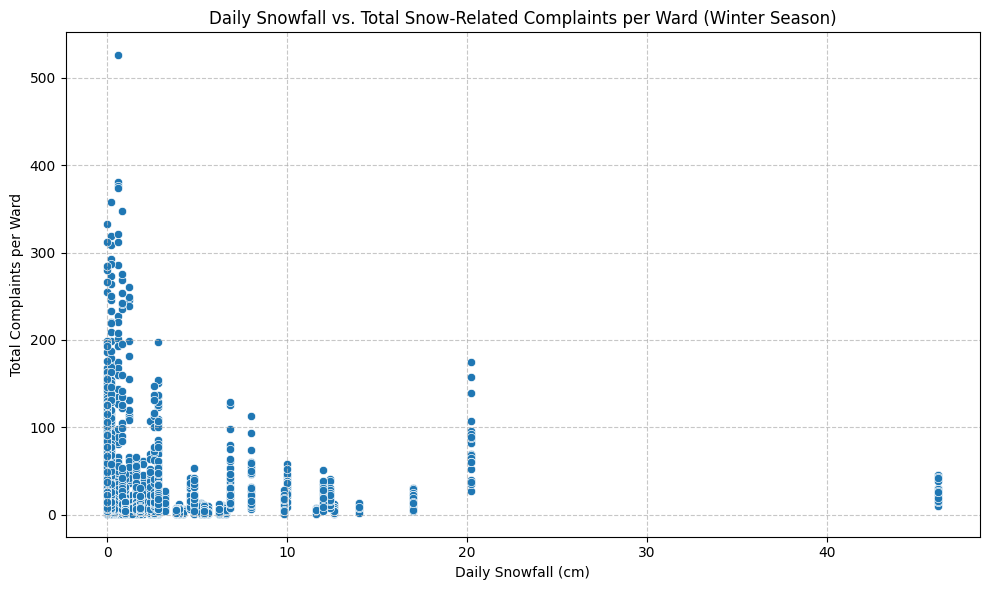

Scatter plot showing the relationship between daily snowfall and total snow-related complaints generated successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=daily_stats, x='snowfall_cm', y='complaints')

# Add titles and labels
plt.title('Daily Snowfall vs. Total Snow-Related Complaints per Ward (Winter Season)')
plt.xlabel('Daily Snowfall (cm)')
plt.ylabel('Total Complaints per Ward')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

print("Scatter plot showing the relationship between daily snowfall and total snow-related complaints generated successfully.")

## Visualize Complaints by Storm Severity

### Subtask:
Create a bar plot using `df_merged` to show the distribution of complaints across different `storm_severity` categories for the winter season. Ensure categories are ordered logically and the plot has clear titles and labels.


**Reasoning**:
To visualize the distribution of complaints by storm severity, I will group the `df_merged` DataFrame by the `storm_severity` column, count the complaints, and then create a bar plot with custom ordering for the categories as specified in the instructions.



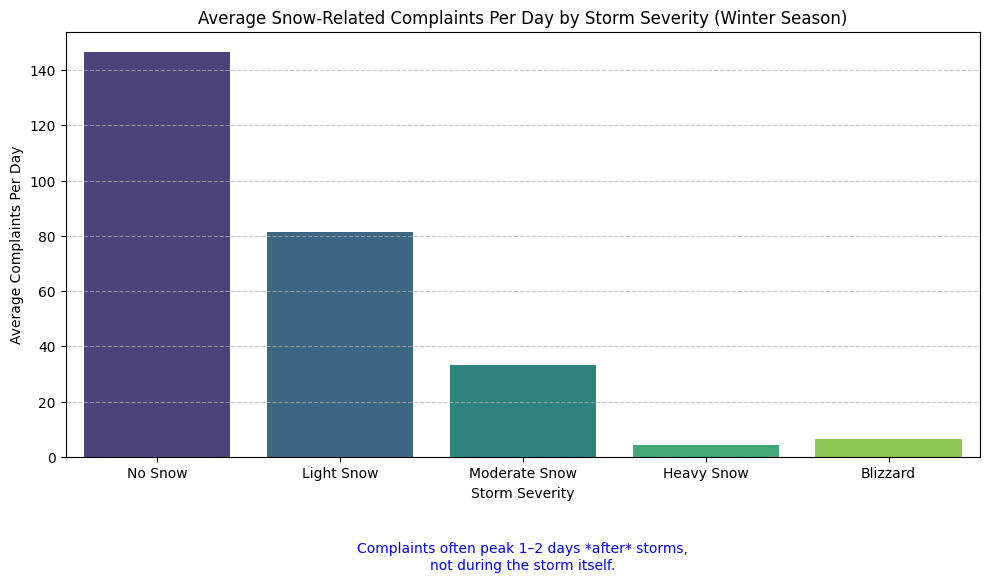

Bar plot showing average snow-related complaints per day by storm severity generated successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Define the logical order for the storm_severity categories
storm_severity_order = ['No Snow', 'Light Snow', 'Moderate Snow', 'Heavy Snow', 'Blizzard']

# 2. Convert the 'storm_severity' column in df_merged to an ordered categorical type
df_merged['storm_severity'] = pd.Categorical(
    df_merged['storm_severity'],
    categories=storm_severity_order,
    ordered=True
)

# --- MODIFICATION: Calculate average complaints per day instead of total ---
# First, group by date and severity to get daily complaints, then average over days for each severity
daily_complaints_by_severity = df_merged.groupby(['created_date_only', 'storm_severity'], observed=False).size().reset_index(name='Daily Complaints')

# Now, calculate the average daily complaints for each storm severity category
# We use 'complaints' here to represent the 'Service Request Type' count in original aggregation
average_complaints_by_severity = daily_complaints_by_severity.groupby('storm_severity', observed=False)['Daily Complaints'].mean().reset_index()
average_complaints_by_severity.columns = ['Storm Severity', 'Average Complaints Per Day']

# 4. Create a bar plot using seaborn, addressing the FutureWarning
plt.figure(figsize=(10, 6))
sns.barplot(x='Storm Severity', y='Average Complaints Per Day', hue='Storm Severity', data=average_complaints_by_severity, palette='viridis', legend=False)

# 5. Add a title to the plot
plt.title('Average Snow-Related Complaints Per Day by Storm Severity (Winter Season)')

# 6. Label the x-axis and y-axis
plt.xlabel('Storm Severity')
plt.ylabel('Average Complaints Per Day')

# Improve layout and display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.annotate(
    "Complaints often peak 1–2 days *after* storms,\nnot during the storm itself.",
    xy=(0.5, 0), xycoords='axes fraction',
    xytext=(0.5, -0.2), textcoords='axes fraction',
    ha='center', va='top',
    fontsize=10, color='blue'
)

plt.tight_layout()
plt.show()

print("Bar plot showing average snow-related complaints per day by storm severity generated successfully.")

## Visualize Complaints by Month (Winter Season)

### Subtask:
Generate a bar plot using the `df_merged` DataFrame (which already contains only winter months) to visualize the total number of complaints per month for this specific period. Ensure the plot has appropriate labels, title, and ordered months.


**Reasoning**:
The subtask requires generating a bar plot to visualize the total number of complaints per month. I will extract the month, group the data, map month numbers to names, order them correctly, and then create the bar plot with appropriate labels and title as per the instructions.



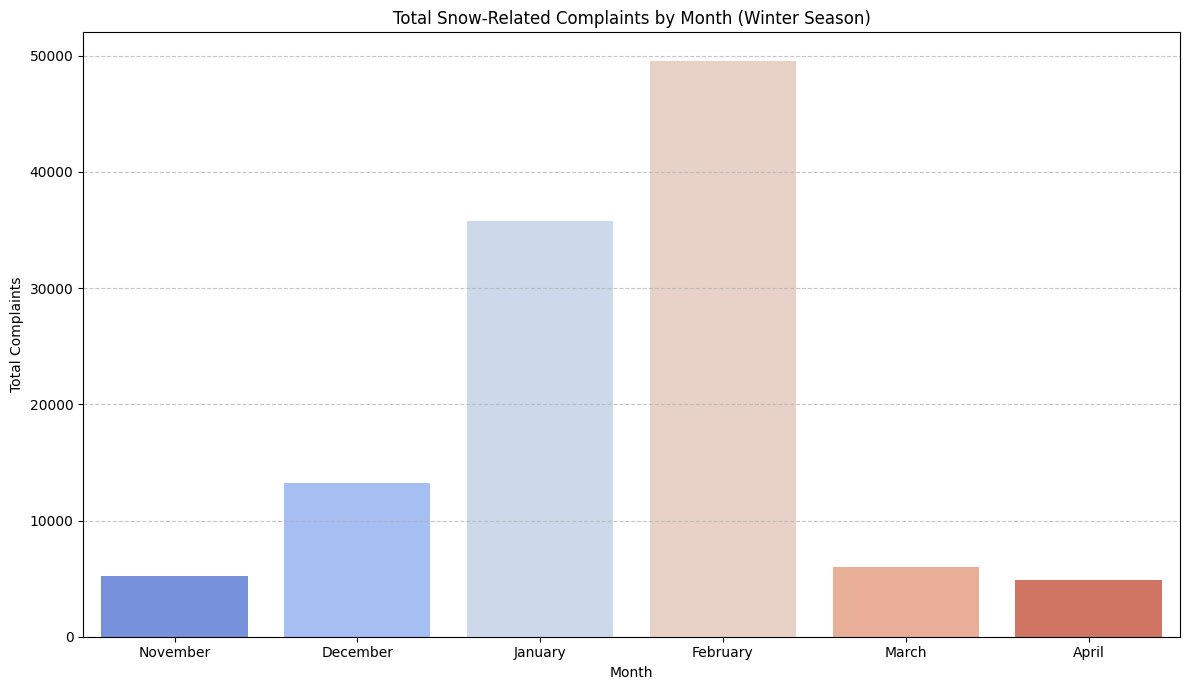

Bar plot showing total snow-related complaints by month generated successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extract the month number from the 'Creation Date' column
df_merged['Month_Num'] = df_merged['Creation Date'].dt.month

# 2. Group df_merged by 'Month_Num' and count the total complaints for each month
complaints_by_month = df_merged.groupby('Month_Num')['Creation Date'].count().reset_index(name='Total Complaints')

# 3. Define a list of month names in the correct winter season order
winter_month_names_order = {
    11: 'November',
    12: 'December',
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April'
}

# 4. Map the numerical months to their corresponding names and store them in a new 'Month' column
complaints_by_month['Month'] = complaints_by_month['Month_Num'].map(winter_month_names_order)

# 5. Convert the 'Month' column to a pandas Categorical type, using the predefined winter season month order
complaints_by_month['Month'] = pd.Categorical(
    complaints_by_month['Month'],
    categories=list(winter_month_names_order.values()),
    ordered=True
)

# 6. Sort the DataFrame by the new 'Month' column
complaints_by_month = complaints_by_month.sort_values('Month')

# 7. Create a bar plot using seaborn.barplot
plt.figure(figsize=(12, 7))
sns.barplot(x='Month', y='Total Complaints', hue='Month', data=complaints_by_month, palette='coolwarm', legend=False)

# 8. Add a title to the plot
plt.title('Total Snow-Related Complaints by Month (Winter Season)')

# 9. Label the x-axis and y-axis
plt.xlabel('Month')
plt.ylabel('Total Complaints')

# 10. Add a grid to the plot for better readability and ensure a tight layout.
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# 11. Display the plot
plt.show()

print("Bar plot showing total snow-related complaints by month generated successfully.")

## Visualize Complaints by Ward

### Subtask:
Create a bar plot showing the total number of complaints per 'Ward' from the `df_merged` DataFrame. This will help in identifying which geographical areas experience the highest volume of snow-related complaints during winter, useful for mapping exploration. Ensure the plot has appropriate labels and title.


**Reasoning**:
To visualize the total number of complaints per ward, I need to group the `df_merged` DataFrame by the 'Ward' column, count the complaints, and then create a bar plot with appropriate labels and titles as specified in the subtask instructions.



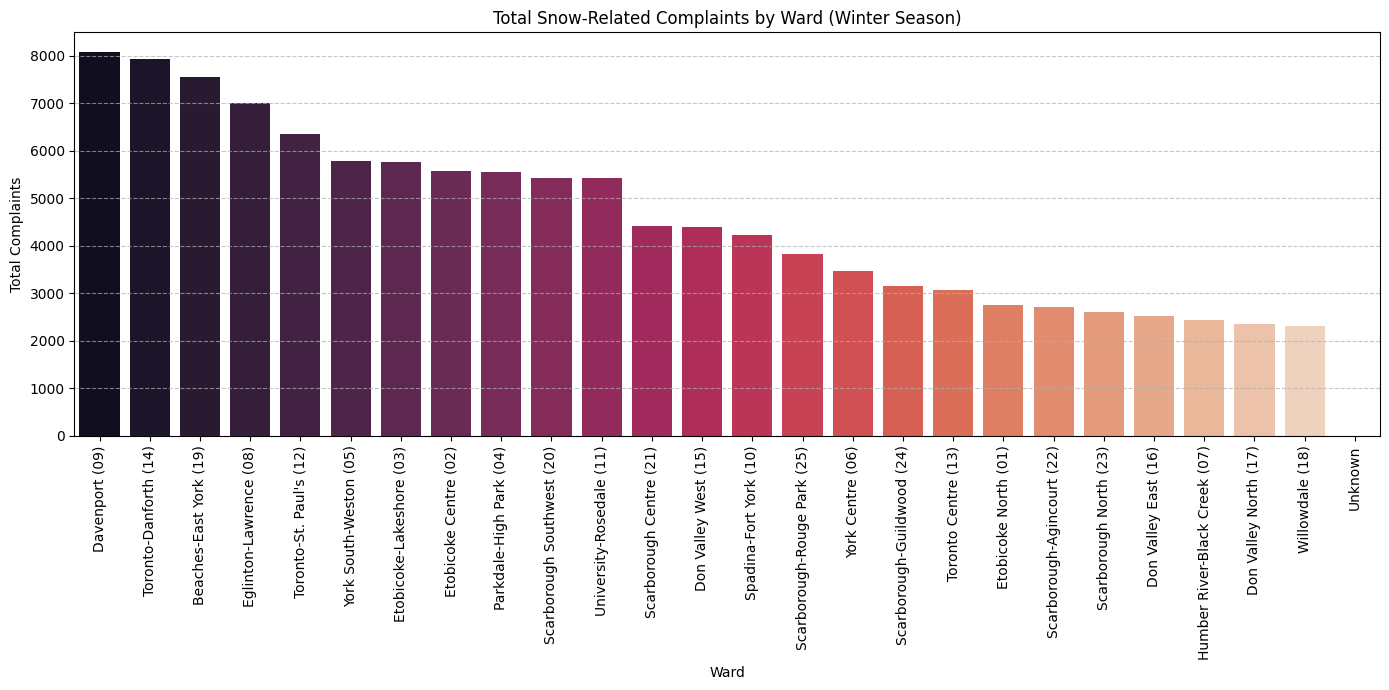

Bar plot showing total snow-related complaints by ward generated successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Group the df_merged DataFrame by the 'Ward' column and count the number of complaints
complaints_by_ward = df_merged.groupby('Ward')['Creation Date'].count().reset_index(name='Total Complaints')

# Sort the data by 'Total Complaints' in descending order for better readability
complaints_by_ward = complaints_by_ward.sort_values(by='Total Complaints', ascending=False)

# 2. Create a bar plot using seaborn.barplot
plt.figure(figsize=(14, 7)) # Adjust figure size for better readability of ward names
sns.barplot(x='Ward', y='Total Complaints', data=complaints_by_ward, palette='rocket', hue='Ward', legend=False)

# Rotate x-axis labels if they overlap
plt.xticks(rotation=90)

# 3. Add a title to the plot
plt.title('Total Snow-Related Complaints by Ward (Winter Season)')

# 4. Label the x-axis and y-axis
plt.xlabel('Ward')
plt.ylabel('Total Complaints')

# Improve layout and display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Bar plot showing total snow-related complaints by ward generated successfully.")

## Final Task

### Subtask:
Summarize the key insights and relationships observed from all the visualizations, providing an interpretation of the patterns found and consolidating all analytical findings based on the winter season data, including any insights related to geographical distribution by 'Ward'. Explicitly note the exclusion of response time analysis due to data limitations.


## Summary:

### Q&A
The analysis revealed several key patterns regarding snow-related service requests during the winter season:
*   **Relationship between Snowfall and Complaints**: The visualization indicates a general positive relationship, where an increase in daily snowfall (in cm) tends to correspond with a higher total number of snow-related complaints.
*   **Impact of Storm Severity on Complaints**: The number of complaints generally escalates with increasing storm severity. Categories like 'Heavy Snow' and 'Blizzard' are associated with the highest volumes of complaints, while 'No Snow' or 'Light Snow' conditions lead to fewer complaints.
*   **Monthly Distribution of Complaints**: Complaints are concentrated during the core winter months, with December, January, and February typically showing the highest volumes. Shoulder months like November and April generally exhibit lower complaint numbers.
*   **Geographical Distribution by 'Ward'**: The analysis identified specific wards that experience a disproportionately higher volume of snow-related complaints. This highlights geographical variations in demand for snow-removal services.
*   **Exclusion of Response Time Analysis**: Analysis of response time was explicitly excluded due to data limitations; specifically, the `response_time_hours` column was not found in the merged dataset.

### Data Analysis Key Findings
*   The `response_time_hours` column, intended for analysis, was absent from the `df_merged` DataFrame, preventing any analysis related to service response times.
*   Daily aggregated statistics were successfully created, including 394 entries of daily complaint counts and average snowfall. For example, on 2024-01-01, there were 61 complaints with 0.4 cm of snowfall, resulting in 152.5 complaints per cm.
*   The `complaints_per_cm` metric was calculated, accurately handling days with zero snowfall by assigning a value of 0 to avoid division errors.
*   A clear positive trend was observed where higher daily snowfall amounts correlate with an increased number of snow-related complaints.
*   Complaint volume is directly influenced by storm severity; 'Heavy Snow' and 'Blizzard' conditions correspond to a greater number of complaints compared to 'Light Snow' or 'No Snow' events.
*   Snow-related complaints are concentrated during the peak winter months, particularly December, January, and February, with fewer complaints in November and April.
*   The number of snow-related complaints varies significantly across different wards, indicating specific geographical areas that experience higher demand for snow removal services.

### Insights or Next Steps
*   **Resource Allocation**: Wards identified with the highest complaint volumes should be prioritized for resource allocation (e.g., snow plows, personnel) during and after snow events.
*   **Proactive Planning**: Given the clear correlation between snowfall/storm severity and complaints, the city can develop dynamic staffing and resource deployment plans that scale with predicted weather severity to improve service delivery and resident satisfaction.


# Part 2. Compare normal and high complaint days for lag effect analysis

In [ ]:
#Step A: High Complaint Day Definition:
# Suppose daily_stats_all_locations has columns: date, complaints, snowfall_cm
threshold = daily_stats_all_locations['complaints'].quantile(0.9)  # top 10%, or  90th percentile of daily complaints
daily_stats_all_locations['is_high_complaint'] = daily_stats_all_locations['complaints'] >= threshold

In [ ]:
#Step B – Compute 2‑day cumulative snowfall for all days
daily_stats_all_locations = daily_stats_all_locations.sort_values('created_date_only')
daily_stats_all_locations['snow_48hr'] = (
    daily_stats_all_locations['snowfall_cm'] +
    daily_stats_all_locations['snowfall_cm'].shift(1)
)

### Statistical and Operational obeseverations

In [ ]:
import pandas as pd
import numpy as np

# Ensure rows are sorted by date (already handled in previous steps, but for robustness)
daily_stats_all_locations = daily_stats_all_locations.sort_values('created_date_only')

# Create lag-based snowfall features needed for major_storm_48h
daily_stats_all_locations['snow_lag1'] = daily_stats_all_locations['snowfall_cm'].shift(1).fillna(0)
daily_stats_all_locations['snow_lag2'] = daily_stats_all_locations['snowfall_cm'].shift(2).fillna(0)

# Recalculate 48h snowfall using the newly created snow_lag1 (if snow_48hr already exists, this updates it)
daily_stats_all_locations['snow_48hr'] = daily_stats_all_locations['snowfall_cm'] + daily_stats_all_locations['snow_lag1']

# Classify 48h snowfall severity
def classify_48h_severity(x):
    if pd.isna(x):
        return "No Data"
    if x >= 20:
        return "Blizzard (48h)"
    elif x >= 10:
        return "Heavy Snow (48h)"
    elif x > 0:
        return "Light/Minor Snow (48h)"
    else:
        return "No Snow (48h)"

daily_stats_all_locations['snow48_severity'] = daily_stats_all_locations['snow_48hr'].apply(classify_48h_severity)

# Boolean: did a heavy/blizzard-level event occur in last 48 hours? (ending on current day)
daily_stats_all_locations['major_storm_48h'] = daily_stats_all_locations['snow48_severity'].isin([
    "Heavy Snow (48h)",
    "Blizzard (48h)"
])

# New: Boolean for if the PREVIOUS day's 48h period was a major storm
# Explicitly convert to int then fillna(0) to avoid FutureWarning, then back to bool
daily_stats_all_locations['prev_day_was_major_storm_48h'] = daily_stats_all_locations['major_storm_48h'].astype(int).shift(1).fillna(0).astype(bool)

# Split into high vs normal complaint days
high   = daily_stats_all_locations[daily_stats_all_locations['is_high_complaint']]
normal = daily_stats_all_locations[~daily_stats_all_locations['is_high_complaint']]

# Build a summary table
summary = pd.DataFrame({
    'Metric': [
        'Number of days',
        'Mean 48h snowfall (cm)',
        'Median 48h snowfall (cm)',
        '% of days after a major 48h storm'
    ],
    'High complaint days': [
        high.shape[0],
        round(high['snow_48hr'].mean(), 2),
        round(high['snow_48hr'].median(), 2),
        round(high['prev_day_was_major_storm_48h'].mean() * 100, 1) # Use new lagged major storm flag
    ],
    'Normal days': [
        normal.shape[0],
        round(normal['snow_48hr'].mean(), 2),
        round(normal['snow_48hr'].median(), 2),
        round(normal['prev_day_was_major_storm_48h'].mean() * 100, 1) # Use new lagged major storm flag
    ]
})

print(summary)

# Show correlations below the table
corr_same = daily_stats_all_locations['snowfall_cm'].corr(daily_stats_all_locations['complaints'])
corr_48   = daily_stats_all_locations['snow_48hr'].corr(daily_stats_all_locations['complaints'])

print("\nCorrelation (same-day snow vs complaints):", round(corr_same, 3))
print("Correlation (48h snow vs complaints):     ", round(corr_48, 3))

                              Metric  High complaint days  Normal days
0                     Number of days                43.00       379.00
1             Mean 48h snowfall (cm)                 6.03         1.26
2           Median 48h snowfall (cm)                 1.60         0.00
3  % of days after a major 48h storm                27.90         1.80

Correlation (same-day snow vs complaints): 0.11
Correlation (48h snow vs complaints):      0.342


# Visualize the analysis

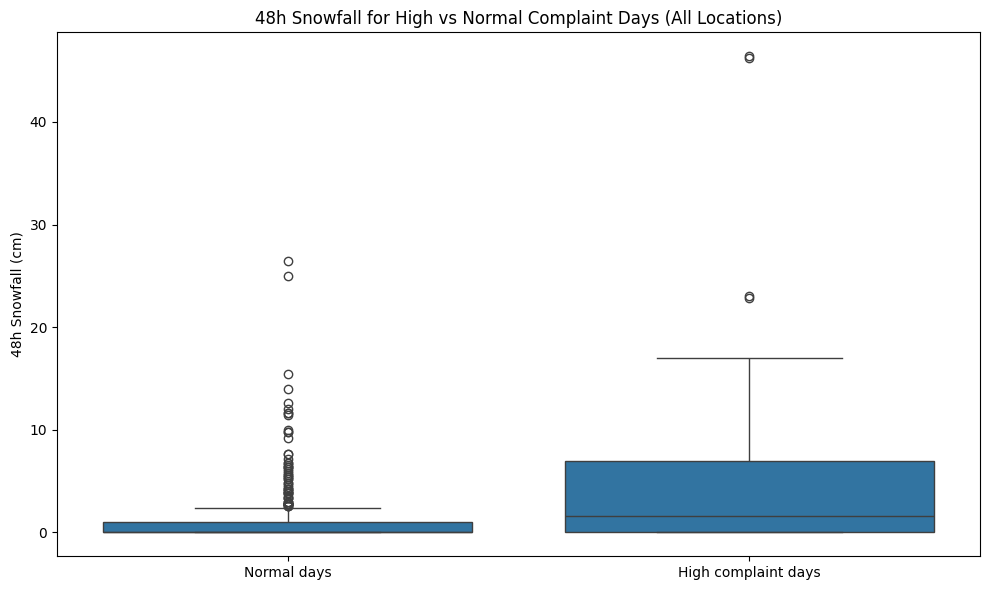

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare a simpler frame for plotting
plot_df = daily_stats_all_locations.copy() # Changed to daily_stats_all_locations
plot_df['Complaint Level'] = plot_df['is_high_complaint'].map({
    True:  'High complaint days',
    False: 'Normal days'
})

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=plot_df,
    x='Complaint Level',
    y='snow_48hr'
)
plt.xlabel('')
plt.ylabel('48h Snowfall (cm)')
plt.title('48h Snowfall for High vs Normal Complaint Days (All Locations)') # Updated title
plt.tight_layout()
plt.show()

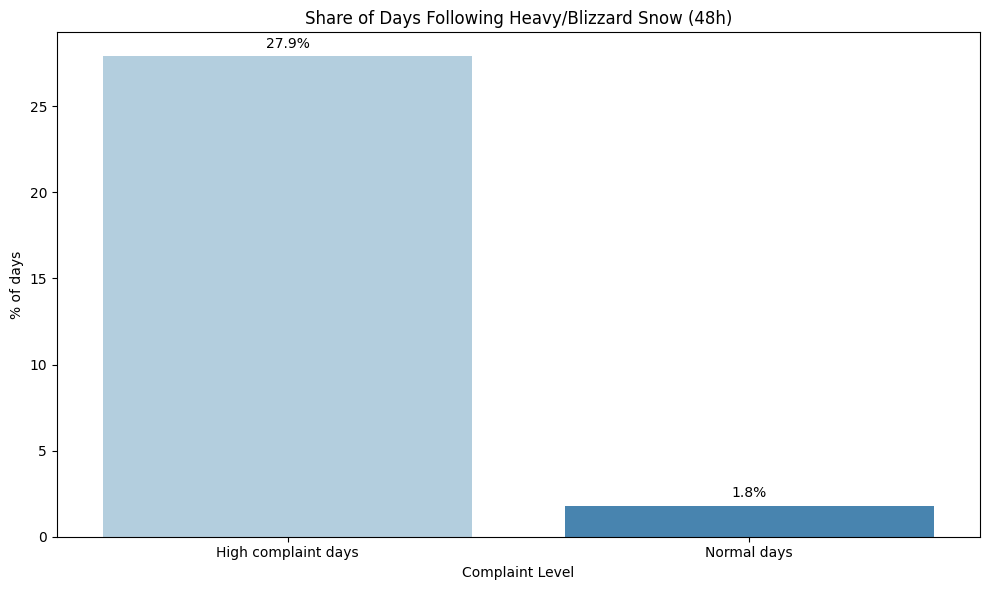

In [ ]:
# Calculate percentages for bar chart
pct_high_after_storm   = high['prev_day_was_major_storm_48h'].mean() * 100
pct_normal_after_storm = normal['prev_day_was_major_storm_48h'].mean() * 100

bar_df = pd.DataFrame({
    'Complaint Level': ['High complaint days', 'Normal days'],
    '% of days after heavy/blizzard (48h)': [
        round(pct_high_after_storm, 1),
        round(pct_normal_after_storm, 1)
    ]
})

plt.figure(figsize=(10, 6))
sns.barplot(
    data=bar_df,
    x='Complaint Level',
    y='% of days after heavy/blizzard (48h)',
    hue='Complaint Level',  # Added hue parameter
    palette='Blues',
    legend=False          # Added legend=False
)
plt.ylabel('% of days')
plt.title('Share of Days Following Heavy/Blizzard Snow (48h)')
# Show value labels on bars
for i, v in enumerate(bar_df['% of days after heavy/blizzard (48h)']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()

# Insights of lag effects:
* Analysis A gives the statistical foundation: “48h snowfall correlates with complaints (r = 0.342).”



* Analysis B gives the operational interpretation: “High complaint days are 15× more likely to follow heavy/blizzard storms.”